# PROC FASTCLUSによる加入者行動のK平均法セグメンテーション


## エグゼクティブサマリー

このノートブックは、Base SASのK平均法クラスタリング手続きである`PROC FASTCLUS`を使用して、100人のモバイル加入者からなる合成データベースを行動クラスターに分割します。7つの利用特徴量は`PROC STDIZE`によってzスコアに標準化され、大きさの異なる変数(通話時間、SMS件数)がユークリッド距離を支配しないようにした上で、`PROC FASTCLUS`が3つのクラスターを当てはめます。この手続きはクラスター内RMS偏差、セグメンテーションが加入者ベースをどれだけ明確に分離しているかを示す全体R二乗値とpseudo-F値(ここでは全体R二乗値0.575、pseudo-F値65.75)を報告し、すべての加入者に`CLUSTER`ラベルを付与したスコアリング済みテーブルを出力します。これらのラベルを元のスケールのデータに結合し、ペルソナをプロファイリングして、下流のアクティベーションへ割り当てを引き渡します。

## データソース

| データセット | 説明 | 行数 | 主要変数 |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | `call streaminit` / `rand()`でインライン生成した、モバイル通信事業者の加入者ベースの合成月次行動スナップショット。3つの潜在的な行動タイプ(ヘビーデータ利用、音声中心、低利用)にノイズを混ぜ合わせている。 | 100 | `subscriber_id`、`tenure_months`、`monthly_data_gb`、`voice_minutes`、`sms_count`、`arpu`、`intl_minutes`、`support_calls`、`data_plan`(名義)、`region`(名義) |

# 加入者行動のK平均法セグメンテーション

**業界:** 通信 &nbsp;|&nbsp; **手続き:** `PROC FASTCLUS`(Base SASのK平均法クラスタリング)

モバイル通信事業者が抱える加入者の月次行動――データ欲求、通話習慣、支出、サポートへの負担――は、いくつかの認識可能なパターンに分類されます。これらのパターンを発見することで、事業者は解約防止施策を調整し、適切なバンドルをアップセルし、類似顧客を獲得できます。このノートブックは、現実的な加入者スナップショットの生成、特徴量の標準化、`PROC FASTCLUS`によるクラスタリング、全加入者へのスコアリング、実用的なペルソナへのセグメントプロファイリングという行動セグメンテーションを一気通貫で構築します。`PROC FASTCLUS`はまさにこの排他的K平均法タスク向けに設計されており、完全な距離行列を構築するのではなくデータを1回走査するため、非常に大規模な加入者ベースにもスケールします。

## 1. 合成加入者ベースの生成

3つの潜在的行動アーキタイプ――**ヘビーデータストリーマー**、**音声中心の伝統派**、**軽度/低利用**の顧客――から抽出した100人の加入者をシミュレートし、境界が(現実と同様に)曖昧になるようノイズを混ぜます。各加入者は`data_plan`と`region`という2つのカテゴリ属性も持ち、後でセグメントの*プロファイリング*に使用します。シードによりデータは再現可能です。

In [1]:
/* -----------------------------------------------------------
   合成モバイル加入者スナップショット(100行)。
   3つの潜在的行動アーキタイプ + ノイズ、
   セグメントプロファイリング用の2つのカテゴリ属性付き。
   ----------------------------------------------------------- */
データ subscribers;
    呼出 streaminit(20260531);

    長さ data_plan $30 region $12;

    繰返 subscriber_id = 100001 から 100100;

        /* 潜在的アーキタイプ: 1=ヘビーデータ, 2=音声, 3=低利用 */
        u = rand('uniform');
        もし      u < 0.38 なら archetype = 1;
        他 もし u < 0.70 なら archetype = 2;
        他                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        もし archetype = 1 なら 繰返;             /* ヘビーデータストリーマー */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        終了;
        他 もし archetype = 2 なら 繰返;        /* 音声中心 */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        終了;
        他 繰返;                              /* 低利用 */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        終了;

        もし planpick = 1 なら data_plan = "プリペイド";
        他 もし planpick = 2 なら data_plan = "ポストペイドM";
        他 data_plan = "無制限";

        region_pick = rand('table', 0.30, 0.28, 0.22, 0.20);
        もし region_pick = 1 なら region = "北部";
        他 もし region_pick = 2 なら region = "南部";
        他 もし region_pick = 3 なら region = "東部";
        他 region = "西部";

        /* 集計しやすい精度に丸める */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        出力;
    終了;

    保持 subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
実行;


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds


## 2. 特徴量分布の確認

クラスタリングの前に、各行動特徴量のスケールと広がりを確認します。ギガバイト、分、ドル、件数という大きく異なる単位こそが、クラスタリング前に区間変数を標準化する理由です。そうしなければ、`voice_minutes`のような大きさの変数が、`PROC FASTCLUS`が最小化するユークリッド距離を支配してしまいます。

                                                  The MEANS Procedure

 Variable         Label                                N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -----------------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    契約期間(月)                            100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  月間データ量(GB)                         100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    通話時間(分)                            100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        SMS件数                              100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes     国際通話時


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


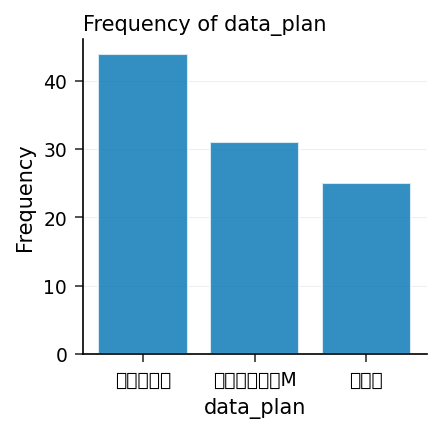

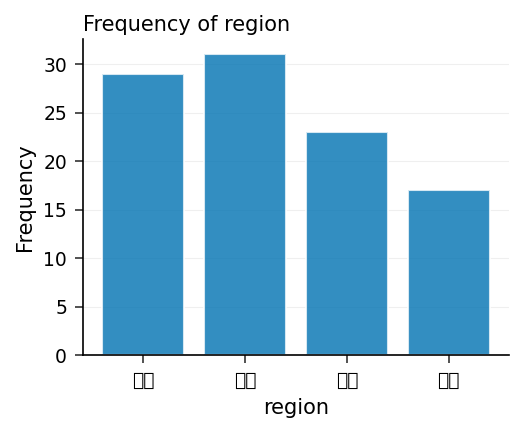

In [2]:
/* クラスタリング入力変数の要約統計量 */
処理 平均 データ=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    変数 tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    見出 tenure_months   = "契約期間(月)"
          monthly_data_gb = "月間データ量(GB)"
          voice_minutes   = "通話時間(分)"
          sms_count       = "SMS件数"
          intl_minutes    = "国際通話時間(分)"
          arpu            = "ARPU(平均収益/加入者)"
          support_calls   = "サポート問合せ件数";
実行;

/* 2つのカテゴリ入力変数の度数 */
処理 度数 データ=subscribers;
    TABLES data_plan region / nocum;
    見出 data_plan = "データプラン"
          region    = "地域";
実行;

## 3. 特徴量をzスコアに標準化

`PROC FASTCLUS`はユークリッド距離を最小化するため、数百分単位で測定される変数は一桁ギガバイト単位の変数を圧倒してしまいます。`METHOD=STD`を指定した`PROC STDIZE`は各区間特徴量を平均0、標準偏差1に再スケーリングし、距離計算においてすべての行動に等しい重みを与えます。カテゴリ列と識別子はそのまま通過するため、後でクラスターを元のスケールでプロファイリングできます。

In [3]:
/* 区間特徴量をzスコア化し、IDとカテゴリ変数はそのまま通過させる */
処理 stdize データ=subscribers out=subs_std METHOD=std;
    変数 tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
実行;


NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. K平均法セグメンテーションの当てはめ

`PROC FASTCLUS`で3つのセグメントを当てはめます。`MAXCLUSTERS=3`が*k*を設定し、`MAXITER=20`によりクラスター中心が収束するまで反復します。この手続きは**クラスターサマリー**(クラスターごとのサイズとクラスター内RMS偏差)、**変数の統計量**(各特徴量が寄与するR二乗値)、3つのクラスターが加入者ベースをどれだけ明確に分離しているかを示す**全体R二乗値**と**pseudo-F値**、そして標準化スケールでの**クラスター平均**を報告します。`OUT=scored`は入力行に`CLUSTER`ラベルと各加入者からそのクラスターシードまでの`DISTANCE`を付与して書き出します。

In [4]:
/* 標準化した特徴量でK平均法を当てはめる: 3セグメント */
処理 FASTCLUS データ=subs_std maxclusters=3 MAXITER=20 out=scored;
    変数 tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
実行;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. セグメントラベルを元スケールのデータに付与

スコアリング済みテーブルには標準化された特徴量が保持されています。プロファイリングのためには、クラスターを実際のギガバイト、分、ドルで記述したいところです。`subscriber_id`をキーに`CLUSTER`ラベルを元の`subscribers`テーブルに結合し、マーケティングが必ず最初に尋ねる質問――*各セグメントの規模は?*――に答えます。

                                                   The FREQ Procedure

クラスター              Frequency    Percent
----------------------------------------
1                         36     36.00
2                         34     34.00
3                         30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


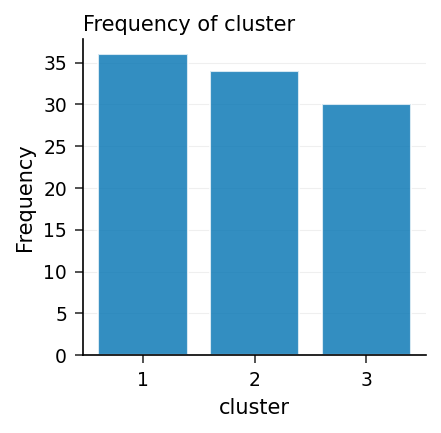

In [5]:
/* クラスターラベルを元スケールのデータに引き継ぐ */
処理 並替 データ=scored(保持=subscriber_id cluster distance) out=clus_assign;
    基準 subscriber_id;
実行;
処理 並替 データ=subscribers out=subs_sorted;
    基準 subscriber_id;
実行;
データ profile;
    結合 subs_sorted clus_assign;
    基準 subscriber_id;
実行;

/* 各セグメントに何人の加入者が該当したか? */
処理 度数 データ=profile;
    TABLES cluster / nocum;
    見出 cluster = "クラスター";
実行;

## 6. セグメントのプロファイリング

クラスターIDは、その中の*行動*を記述するまでは意味を持ちません。元の(標準化されていない)特徴量を`CLUSTER`ごとに平均することで、誰がストリーミングをし、誰が通話をし、誰がほとんどネットワークを使わないのかという各セグメントの背後にあるペルソナが明らかになり、カテゴリの構成比からどのプランと地域が各セグメントに集中しているかがわかります。

                                                  The MEANS Procedure

                                  Analysis Variable : tenure_months 契約期間(月)

        クラスター                    N Obs           Mean
        ---------------------------------------------
        1                           36           28.9
        2                           34           25.8
        3                           30           28.1
        ---------------------------------------------

                               Analysis Variable : monthly_data_gb 月間データ量(GB)

        クラスター                    N Obs           Mean
        ---------------------------------------------
        1                           36            4.0
        2                           34           10.2
        3                           30           44.4
        ---------------------------------------------

                                  Analysis Variable : voice_minutes 通話時間(分)

        クラスター                    N Obs        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


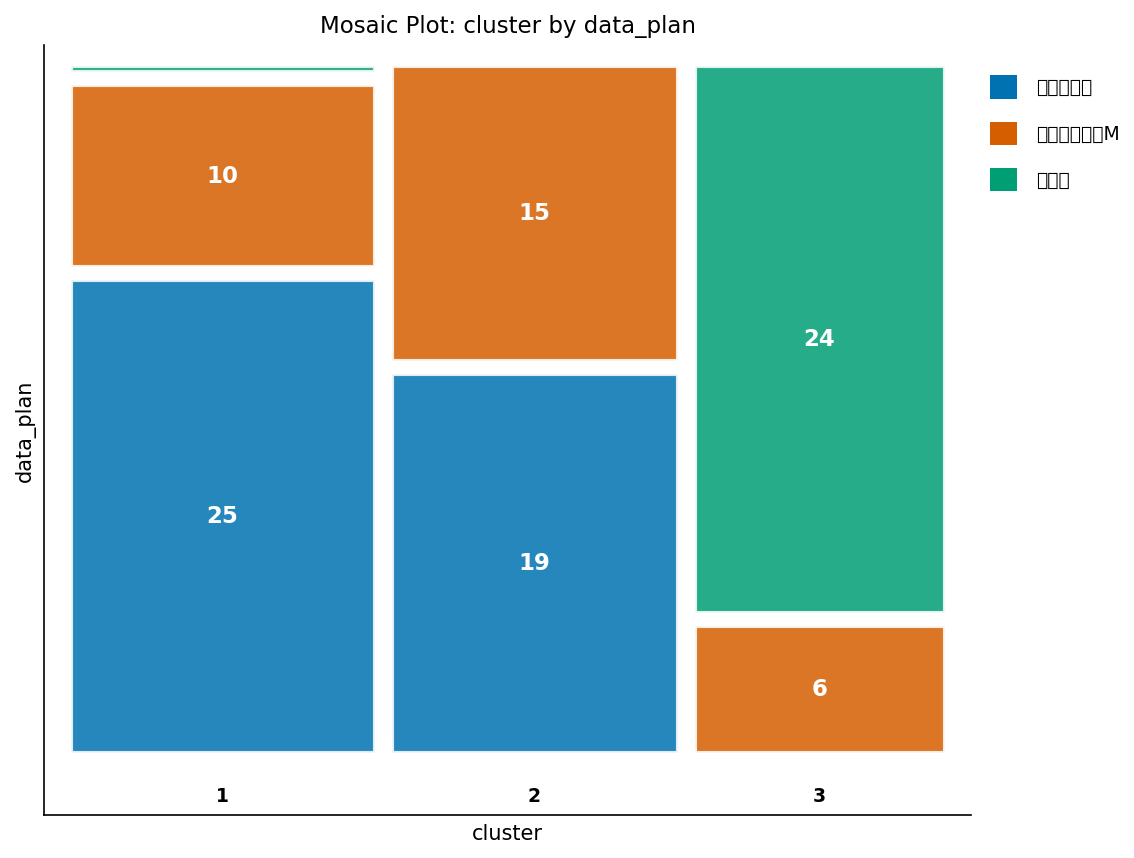

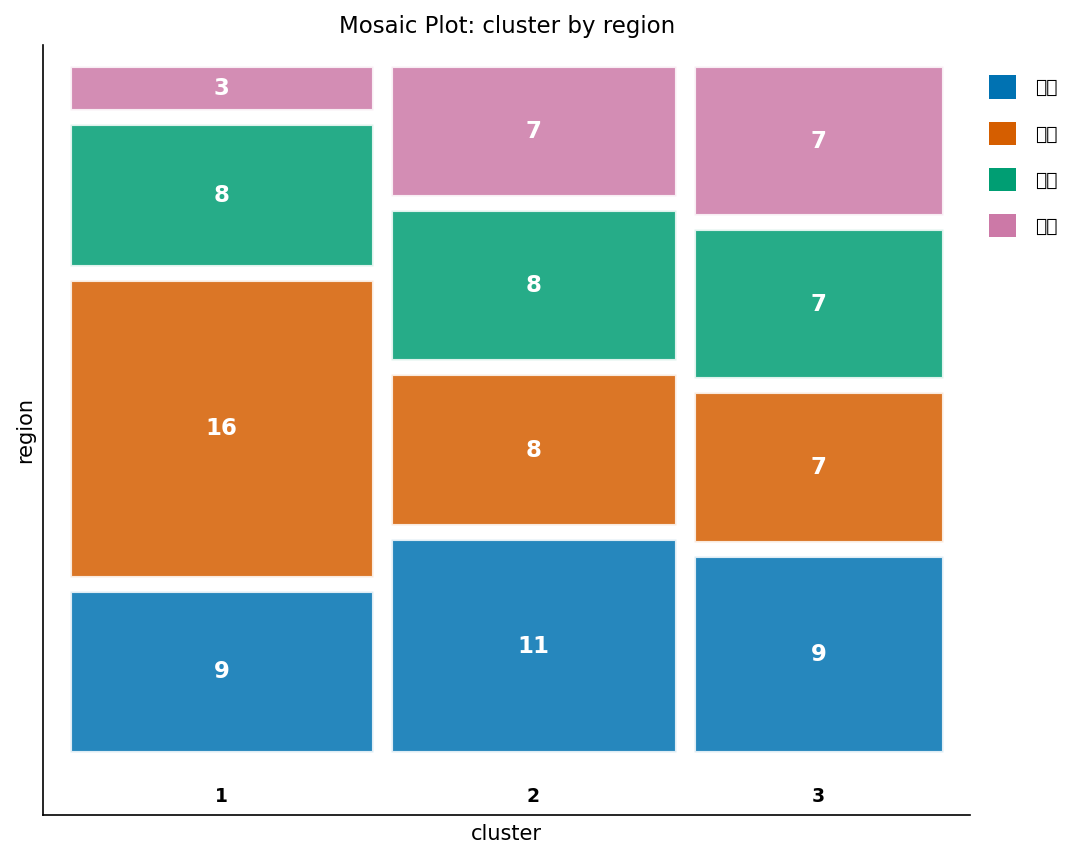

In [6]:
/* 行動プロファイル: セグメントごとの各特徴量の平均 */
処理 平均 データ=profile n mean maxdec=1;
    分類 cluster;
    変数 tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    見出 cluster         = "クラスター"
          tenure_months   = "契約期間(月)"
          monthly_data_gb = "月間データ量(GB)"
          voice_minutes   = "通話時間(分)"
          sms_count       = "SMS件数"
          intl_minutes    = "国際通話時間(分)"
          arpu            = "ARPU(平均収益/加入者)"
          support_calls   = "サポート問合せ件数";
実行;

/* セグメント内のカテゴリ構成比 */
処理 度数 データ=profile;
    TABLES cluster * data_plan / norow nopercent;
    TABLES cluster * region    / norow nopercent;
    見出 cluster   = "クラスター"
          data_plan = "データプラン"
          region    = "地域";
実行;

## 7. セグメントの可視化

図示するとセグメンテーションが具体的になります。データ欲求と通話利用量をセグメントごとに色分けしてプロットし、収益の物語が一目でわかるようセグメントごとのARPU箱ひげ図を追加します。


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


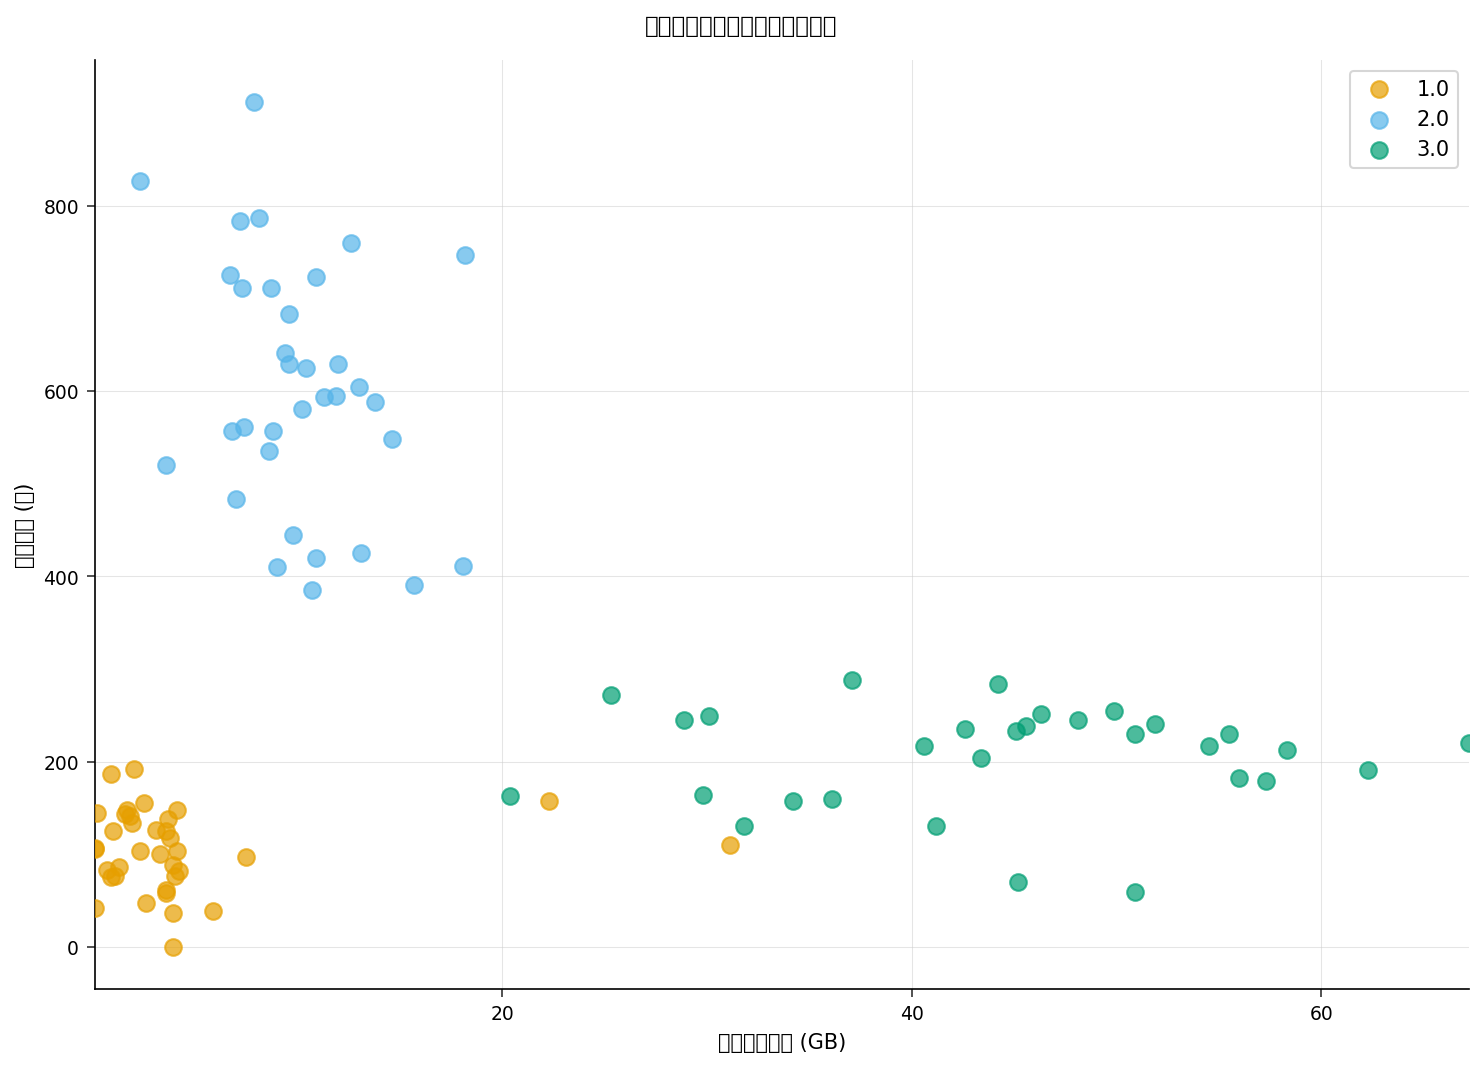

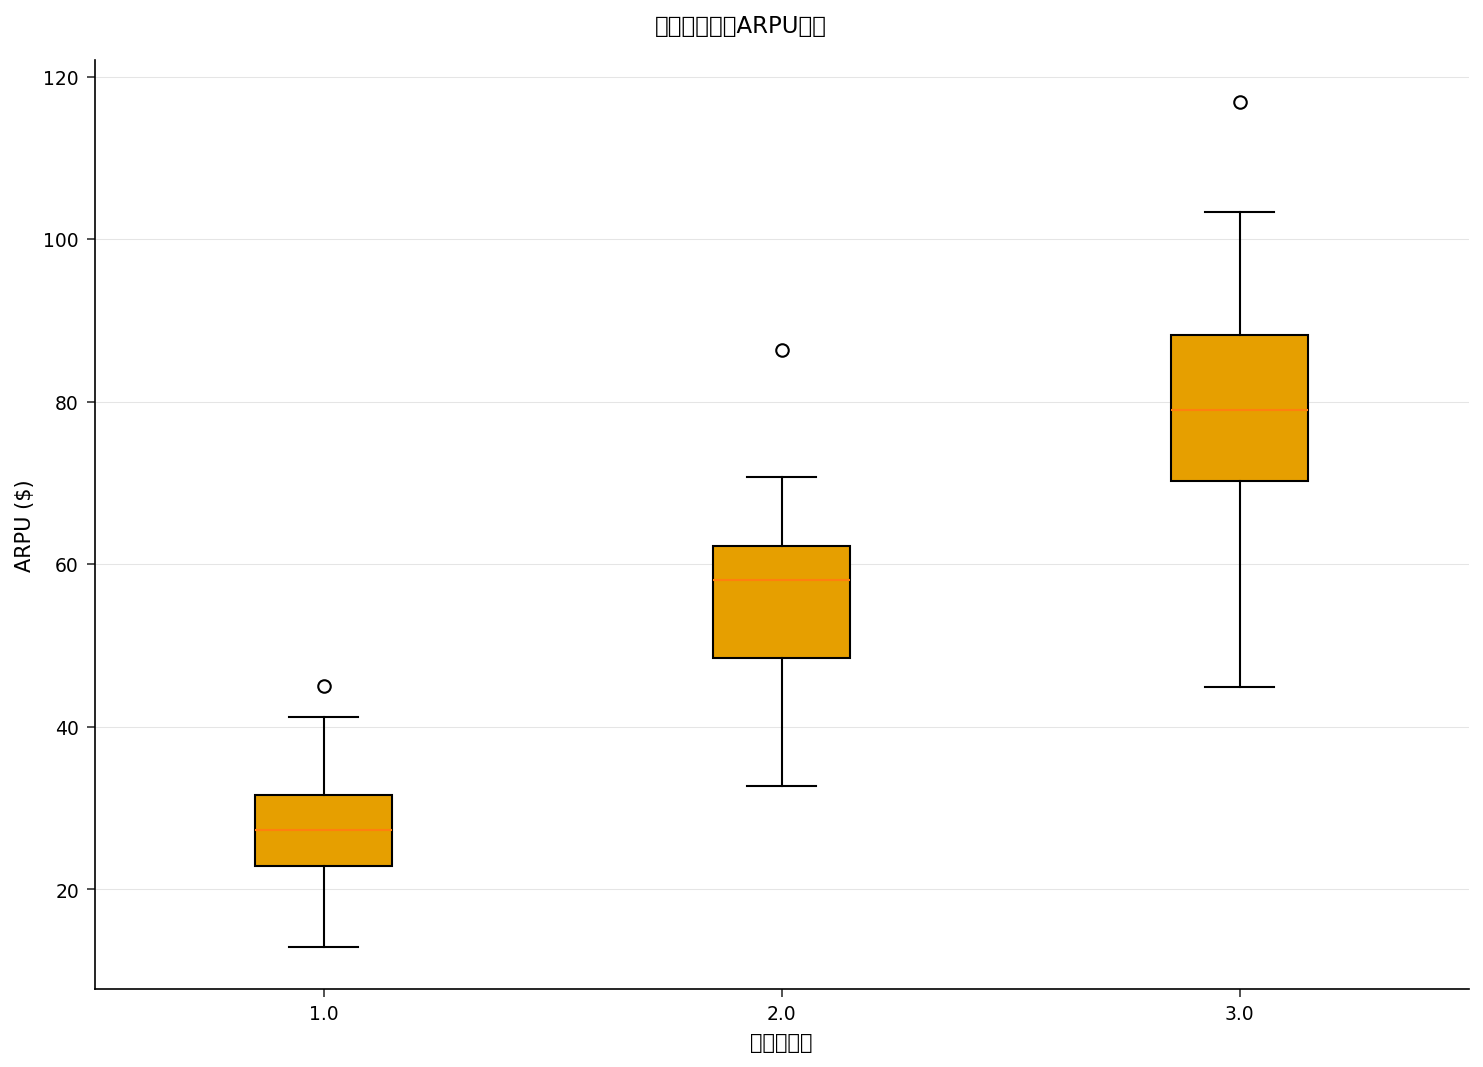

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* 行動マップ: データ量 対 通話時間、セグメントで色分け */
処理 SGPLOT データ=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUP=cluster
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS 見出='月間データ量 (GB)' grid;
    YAXIS 見出='通話時間 (分)'     grid;
    表題 'セグメント別加入者行動マップ';
実行;

/* セグメントごとの収益分布 */
処理 SGPLOT データ=profile;
    VBOX arpu / category=cluster;
    XAXIS 見出='セグメント';
    YAXIS 見出='ARPU ($)' grid;
    表題 'セグメント別ARPU分布';
実行;

## 8. スコアリング済みセグメントのエクスポート

最後に、割り当て結果を下流のCRMおよびキャンペーンシステムに引き渡します。識別子、クラスターラベル、主要な行動フィールドを保持します。

In [8]:
/* アクティベーション用にセグメント割り当てを保存 */
データ subscriber_segments;
    設定 profile;
    保持 subscriber_id cluster tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
実行;

処理 印刷 データ=subscriber_segments(obs=10) noobs 見出;
    見出 subscriber_id   = "加入者ID"
          cluster         = "クラスター"
          tenure_months   = "契約期間(月)"
          monthly_data_gb = "月間データ量(GB)"
          voice_minutes   = "通話時間(分)"
          arpu            = "ARPU(平均収益/加入者)"
          data_plan       = "データプラン"
          region          = "地域";
    表題 'スコアリング済み加入者セグメントのサンプル';
実行;

                                                 スコアリング済み加入者セグメントのサンプル                                                  

      加入者ID            クラスター            契約期間(月)              月間データ量(GB)            通話時間(分)                ARPU(平均収益/加入者)               データプラン      地域
     100001                1                 30                     2.3                104                            28  プリペイド                南部
     100002                2                  8                    10.2                581                         57.78  プリペイド                西部
     100003                2                  8                    10.7                385                         55.66  ポストペイドM              北部
     100004                2                 68                     7.4                561                         70.68  プリペイド                北部
     100005                3                 18                    45.6                239                         63.85  無制限                  北


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## 結果の解釈

`PROC FASTCLUS`は3つの明確に分離されたセグメントを検出しました。当てはめは良好で、**全体R二乗値は0.575**、**pseudo-F値は65.75**であり、3つのクラスターが標準化された特徴量の全変動の約58%を説明していることを意味します。分離はほぼ完全に、私たちが重視する行動シグナル――`voice_minutes`(R二乗値0.858)、`monthly_data_gb`(0.844)、`arpu`(0.771)――によって駆動されており、セグメンテーションを担っている一方、`tenure_months`(0.000)と`support_calls`(0.193)はほとんど寄与していません。これは、加入者が*どのように*ネットワークを利用するかがペルソナを規定するのであって、顧客歴の長さではないことを裏付けています。

3つのセグメントは、元の(標準化されていない)スケールでプロファイリングすると、マーケティングにそのまま使えるペルソナに直接対応します。

| セグメント | n (割合) | 特徴的な行動 | プラン構成 | ペルソナ | 推奨施策 |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30%) | 最高のデータ量: **月44.4 GB**、最高支出**ARPU $79.1**、控えめな通話量(205分) | 24/30 **無制限** | **ヘビーデータストリーマー** | 保護とアップセル: 高速プラン、コンテンツバンドル、端末アップグレード |
| **2** | 34 (34%) | 最高の通話量**月603分**、**SMS 214件**、**国際通話106分**、中程度の支出**ARPU $55.9** | プリペイド + ポストペイドM、**無制限なし** | **音声中心の伝統派** | 国際通話オプション、家族/音声バンドル、ロイヤルティ特典 |
| **1** | 36 (36%) | 最低の利用量: **4.0 GB**、通話104分、最低支出**ARPU $28.0** | 25/36 **プリペイド** | **軽度/低利用** | プランの適正化、自動支払いの促進、利用を伸ばす低価格データスターター |

プラン構成は行動面の読み取りを裏付けています。ヘビーデータセグメントは圧倒的に**無制限**プラン(30件中24件)に偏っており、音声中心セグメントには無制限プランの加入者が**皆無**で、低利用セグメントの大半は**プリペイド**(36件中25件)です。対照的に地域はほぼ均等に3つのセグメントへ分散しており、地理はここでの行動要因ではありません。これはキャンペーンターゲティングにおいてそれ自体有用な発見です。

**なぜ`PROC FASTCLUS`がこの問題に適しているか。** 完全な距離行列を構築するのではなくデータを1回走査することで排他的K平均法を実行するため、この100人の加入者をセグメント化したのと同じプログラムが非常に大規模な加入者ベースにもスケールします。まず`PROC STDIZE`で標準化することで、ギガバイト、分、ドルという単位スケールの偏りを取り除き、すべての行動がユークリッド距離に等しく寄与するようにしました。その後、R二乗値の診断が*どの*特徴量が実際に分割を駆動したかを教えてくれました。スコアリング結果――すべての加入者に付与された`CLUSTER`ラベル――はそのままアクティベーションパイプラインに投入でき、生の行動からターゲットオファーへのループを閉じます。

---

<div style="font-size:11px;color:#9e9e9e">このノートブックはデモンストレーション目的でのみ提供されています。データは合成であり、記載内容はビジネス上の助言を構成するものではありません。</div>